# MCDI504 · Machine Learning I
## Formativa 2 — Fase 2: modelos de regresión supervisada

**Grupo 7:** Alana Bermúdez, Gonzalo Mansilla y Eduardo Villalobos  
**Dataset:** Iris  
**Objetivo:** predecir el ancho del pétalo (cm) a partir del largo del pétalo (cm).  
**Modelos:** regresión lineal simple, árbol de decisión y red neuronal MLP.

Este notebook continúa el proyecto de la Fase 1. La especie se conserva para descripción y para asegurar una partición representativa, pero **no se utiliza como predictor**. Todos los modelos reciben la misma variable de entrada, lo que permite una comparación controlada.

## 1. Configuración reproducible

Se fijan semillas, se registran versiones y se crean carpetas de salida. El dataset se carga desde `scikit-learn`, por lo que no requiere descarga manual.

In [1]:
from pathlib import Path
import sys, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='colorblind')

ROOT = Path.cwd()
FIG_DIR = ROOT / '05_Figuras'
RES_DIR = ROOT / '06_Resultados'
FIG_DIR.mkdir(exist_ok=True)
RES_DIR.mkdir(exist_ok=True)

print(f'Python: {sys.version.split()[0]}')
print(f'pandas: {pd.__version__} | numpy: {np.__version__} | scikit-learn: {sklearn.__version__}')
print(f'Plataforma: {platform.platform()}')
print(f'Semilla: {SEED}')

Python: 3.12.13
pandas: 2.2.2 | numpy: 2.0.2 | scikit-learn: 1.6.1
Plataforma: Linux-6.6.122+-x86_64-with-glibc2.35
Semilla: 42


## 2. Carga, diccionario y validación del dataset

Iris contiene 150 observaciones y cuatro medidas morfológicas continuas. Para esta fase se conserva el mismo conjunto de datos y se redefine el objetivo analítico como regresión de una variable continua.

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.rename(columns={
    'sepal length (cm)': 'largo_sepalo_cm',
    'sepal width (cm)': 'ancho_sepalo_cm',
    'petal length (cm)': 'largo_petalo_cm',
    'petal width (cm)': 'ancho_petalo_cm',
    'target': 'especie_codigo'
})
df['especie'] = df['especie_codigo'].map(dict(enumerate(iris.target_names)))

print('Dimensión:', df.shape)
display(df.head())
display(pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'unicos': df.nunique()
}))
print('Duplicados exactos de medidas y especie:', df.duplicated().sum())

Dimensión: (150, 6)


,largo_sepalo_cm,ancho_sepalo_cm,largo_petalo_cm,ancho_petalo_cm,especie_codigo,especie
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


,tipo,nulos,unicos
largo_sepalo_cm,float64,0,35
ancho_sepalo_cm,float64,0,23
largo_petalo_cm,float64,0,43
ancho_petalo_cm,float64,0,22
especie_codigo,int64,0,3
especie,object,0,3


Duplicados exactos de medidas y especie: 1


In [3]:
assert df.shape == (150, 6)
assert df.isna().sum().sum() == 0
assert set(df['especie']) == {'setosa', 'versicolor', 'virginica'}
assert (df[['largo_sepalo_cm','ancho_sepalo_cm','largo_petalo_cm','ancho_petalo_cm']] > 0).all().all()
print('✅ Validaciones estructurales y de dominio superadas.')

✅ Validaciones estructurales y de dominio superadas.


### Decisiones de calidad

- No existen valores faltantes, por lo que no se aplica imputación ni eliminación de filas.
- Se detecta una combinación repetida de mediciones y especie. Se conserva porque el dataset no posee un identificador individual y una coincidencia morfológica puede corresponder a flores diferentes; eliminarla sin evidencia alteraría la distribución.
- La variable objetivo es `ancho_petalo_cm` y la predictora común es `largo_petalo_cm`.
- `especie` se usa solo para el análisis descriptivo y para estratificar la partición.

## 3. Análisis exploratorio inicial

In [4]:
resumen = df.groupby('especie')[['largo_petalo_cm','ancho_petalo_cm']].agg(['count','mean','std','min','max']).round(3)
display(resumen)
resumen.to_csv(RES_DIR / 'resumen_por_especie.csv', encoding='utf-8-sig')

corr = df[['largo_petalo_cm','ancho_petalo_cm']].corr().iloc[0,1]
print(f'Correlación de Pearson largo–ancho del pétalo: {corr:.4f}')

largo_petalo_cm                         ancho_petalo_cm         \
                     count   mean    std  min  max           count   mean   
especie                                                                     
setosa                  50  1.462  0.174  1.0  1.9              50  0.246   
versicolor              50  4.260  0.470  3.0  5.1              50  1.326   
virginica               50  5.552  0.552  4.5  6.9              50  2.026   

                             
              std  min  max  
especie                      
setosa      0.105  0.1  0.6  
versicolor  0.198  1.0  1.8  
virginica   0.275  1.4  2.5

Correlación de Pearson largo–ancho del pétalo: 0.9629


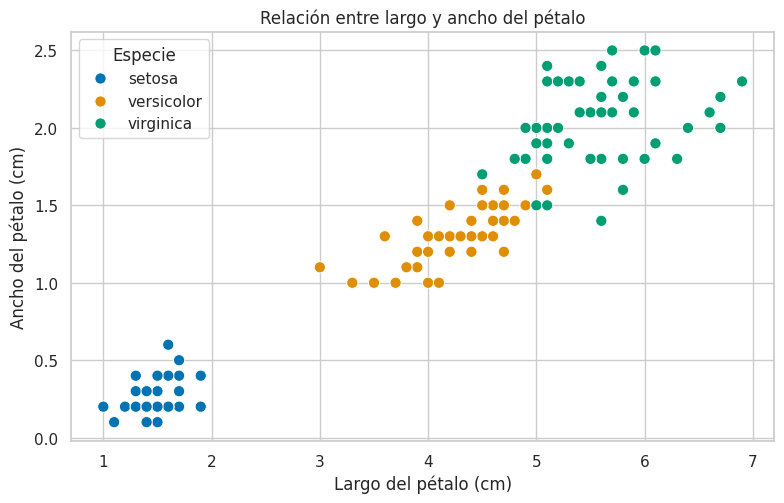

In [5]:
fig, ax = plt.subplots(figsize=(8,5.2))
sns.scatterplot(data=df, x='largo_petalo_cm', y='ancho_petalo_cm', hue='especie', s=65, ax=ax)
ax.set(title='Relación entre largo y ancho del pétalo', xlabel='Largo del pétalo (cm)', ylabel='Ancho del pétalo (cm)')
ax.legend(title='Especie')
fig.tight_layout(); fig.savefig(FIG_DIR/'figura_1_relacion_petalo.png', dpi=220, bbox_inches='tight'); plt.show()

**Interpretación.** Se espera una asociación positiva intensa: a mayor largo del pétalo, mayor ancho. La separación visual por especie explica parte de la estructura, pero la comparación predictiva se restringe deliberadamente a una característica continua para cumplir el modelo lineal simple y mantener igualdad de información entre algoritmos.

## 4. Preparación analítica y partición entrenamiento/prueba

In [6]:
X = df[['largo_petalo_cm']]
y = df['ancho_petalo_cm']
estratos = df['especie_codigo']

X_train, X_test, y_train, y_test, estratos_train, estratos_test = train_test_split(
    X, y, estratos, test_size=0.20, random_state=SEED, stratify=estratos
)

particion = pd.DataFrame({
    'Conjunto':['Entrenamiento','Prueba'],
    'Filas':[len(X_train),len(X_test)],
    'Porcentaje':[len(X_train)/len(X)*100,len(X_test)/len(X)*100]
})
display(particion)
print('Especies en prueba:', estratos_test.value_counts().sort_index().to_dict())

assert len(X_train)==120 and len(X_test)==30
assert estratos_test.value_counts().sort_index().tolist()==[10,10,10]
assert X_train.index.intersection(X_test.index).empty
print('✅ Partición reproducible, disjunta y representativa.')

,Conjunto,Filas,Porcentaje
0,Entrenamiento,120,80.0
1,Prueba,30,20.0


Especies en prueba: {0: 10, 1: 10, 2: 10}
✅ Partición reproducible, disjunta y representativa.


El escalamiento se aplica únicamente dentro del `Pipeline` de la MLP y se ajusta con entrenamiento, evitando fuga de información. La regresión lineal y el árbol trabajan con la escala original; el árbol no necesita estandarización.

## 5. Modelo de regresión lineal simple

In [7]:
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)
pred_lineal = modelo_lineal.predict(X_test)

print(f'Coeficiente: {modelo_lineal.coef_[0]:.6f}')
print(f'Intercepto: {modelo_lineal.intercept_:.6f}')
print(f'Ecuación: ancho_pétalo = {modelo_lineal.intercept_:.4f} + {modelo_lineal.coef_[0]:.4f} × largo_pétalo')

Coeficiente: 0.415587
Intercepto: -0.361761
Ecuación: ancho_pétalo = -0.3618 + 0.4156 × largo_pétalo


**Lectura inicial.** El coeficiente positivo cuantifica el aumento promedio esperado del ancho del pétalo por cada centímetro adicional de largo. El modelo funciona como línea base interpretable y supone una relación lineal global.

## 6. Árbol de decisión para regresión

In [8]:
modelo_arbol = DecisionTreeRegressor(
    criterion='squared_error', max_depth=3, min_samples_split=2,
    min_samples_leaf=4, random_state=SEED
)
modelo_arbol.fit(X_train, y_train)
pred_arbol = modelo_arbol.predict(X_test)

print('Profundidad efectiva:', modelo_arbol.get_depth())
print('Número de hojas:', modelo_arbol.get_n_leaves())
print('Hiperparámetros:', {k:modelo_arbol.get_params()[k] for k in ['criterion','max_depth','min_samples_split','min_samples_leaf','random_state']})

Profundidad efectiva: 3
Número de hojas: 7
Hiperparámetros: {'criterion': 'squared_error', 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 4, 'random_state': 42}


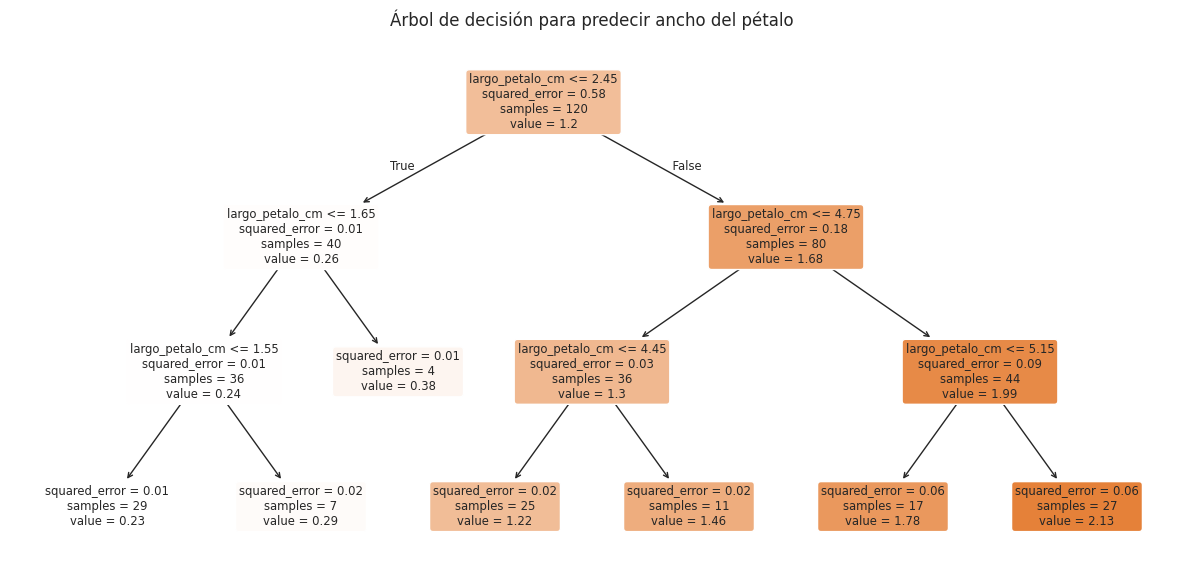

In [9]:
fig, ax = plt.subplots(figsize=(12,6))
plot_tree(modelo_arbol, feature_names=['largo_petalo_cm'], filled=True, rounded=True, precision=2, ax=ax)
ax.set_title('Árbol de decisión para predecir ancho del pétalo')
fig.tight_layout(); fig.savefig(FIG_DIR/'figura_2_arbol.png', dpi=220, bbox_inches='tight'); plt.show()

**Lectura inicial.** La profundidad máxima de 3 y el mínimo de 4 observaciones por hoja son medidas de prepoda. El modelo produce predicciones por tramos y puede capturar cambios locales sin crecer hasta memorizar observaciones individuales.

## 7. Red neuronal MLP para regresión

In [10]:
modelo_mlp = Pipeline([
    ('escalador', StandardScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(16, 8), activation='relu', solver='lbfgs',
        alpha=0.001, max_iter=5000, random_state=SEED
    ))
])
modelo_mlp.fit(X_train, y_train)
pred_mlp = modelo_mlp.predict(X_test)

mlp = modelo_mlp.named_steps['mlp']
print('Arquitectura oculta:', mlp.hidden_layer_sizes)
print('Activación:', mlp.activation, '| Solver:', mlp.solver)
print('Regularización alpha:', mlp.alpha, '| Iteraciones:', mlp.n_iter_)
print('Pérdida final:', round(mlp.loss_, 8))

Arquitectura oculta: (16, 8)
Activación: relu | Solver: lbfgs
Regularización alpha: 0.001 | Iteraciones: 162
Pérdida final: 0.01529547


**Lectura inicial.** La MLP usa dos capas ocultas pequeñas (16 y 8 neuronas), activación ReLU, regularización L2 y el optimizador L-BFGS. El escalamiento es esencial para estabilizar el entrenamiento. Dado que Iris es pequeño, la arquitectura se mantiene deliberadamente acotada.

## 8. Evaluación en datos de prueba

In [11]:
predicciones = {
    'Regresión lineal simple': pred_lineal,
    'Árbol de decisión': pred_arbol,
    'Red neuronal MLP': pred_mlp
}

filas=[]
for nombre,pred in predicciones.items():
    mse=mean_squared_error(y_test,pred)
    filas.append({'Modelo':nombre,'MSE':mse,'RMSE':np.sqrt(mse),'R2':r2_score(y_test,pred)})
resultados=pd.DataFrame(filas).sort_values(['RMSE','R2'],ascending=[True,False]).reset_index(drop=True)
display(resultados.round({'MSE':6,'RMSE':6,'R2':6}))
resultados.to_csv(RES_DIR/'metricas_modelos.csv',index=False,encoding='utf-8-sig')

mejor=resultados.iloc[0]
print(f"Mejor modelo en prueba: {mejor['Modelo']} | RMSE={mejor['RMSE']:.4f} cm | R²={mejor['R2']:.4f}")

,Modelo,MSE,RMSE,R2
0,Red neuronal MLP,0.037018,0.192400,0.935932
1,Árbol de decisión,0.045315,0.212874,0.921571
2,Regresión lineal simple,0.045843,0.214109,0.920658


Mejor modelo en prueba: Red neuronal MLP | RMSE=0.1924 cm | R²=0.9359


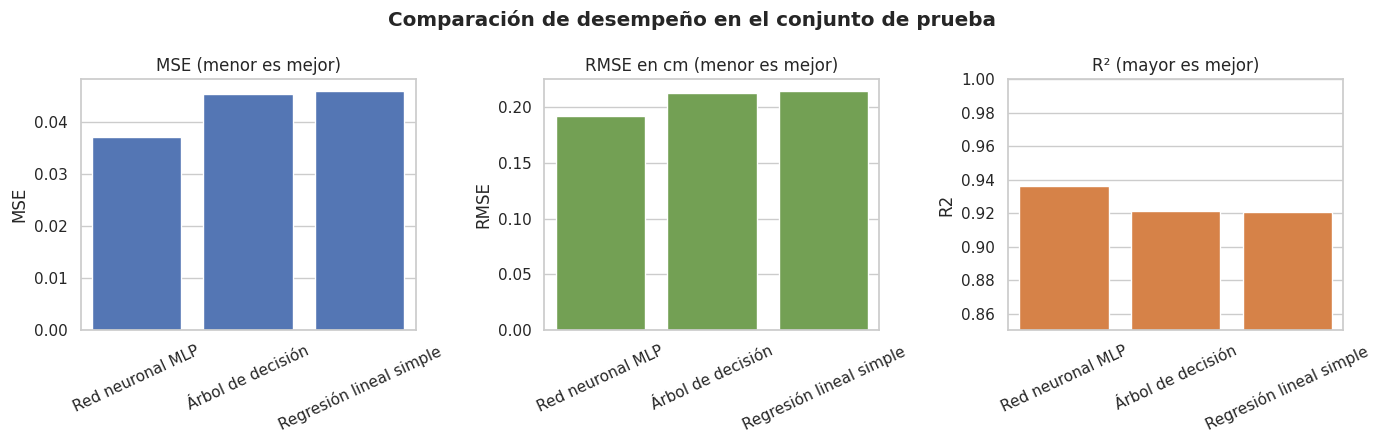

In [12]:
fig, axes = plt.subplots(1,3,figsize=(14,4.5))
orden=resultados['Modelo'].tolist()
sns.barplot(data=resultados,x='Modelo',y='MSE',order=orden,ax=axes[0],color='#4472C4')
sns.barplot(data=resultados,x='Modelo',y='RMSE',order=orden,ax=axes[1],color='#70AD47')
sns.barplot(data=resultados,x='Modelo',y='R2',order=orden,ax=axes[2],color='#ED7D31')
for ax,t in zip(axes,['MSE (menor es mejor)','RMSE en cm (menor es mejor)','R² (mayor es mejor)']):
    ax.set_title(t); ax.set_xlabel(''); ax.tick_params(axis='x',rotation=25)
axes[2].set_ylim(0.85,1.0)
fig.suptitle('Comparación de desempeño en el conjunto de prueba',fontweight='bold')
fig.tight_layout(); fig.savefig(FIG_DIR/'figura_3_metricas.png',dpi=220,bbox_inches='tight'); plt.show()

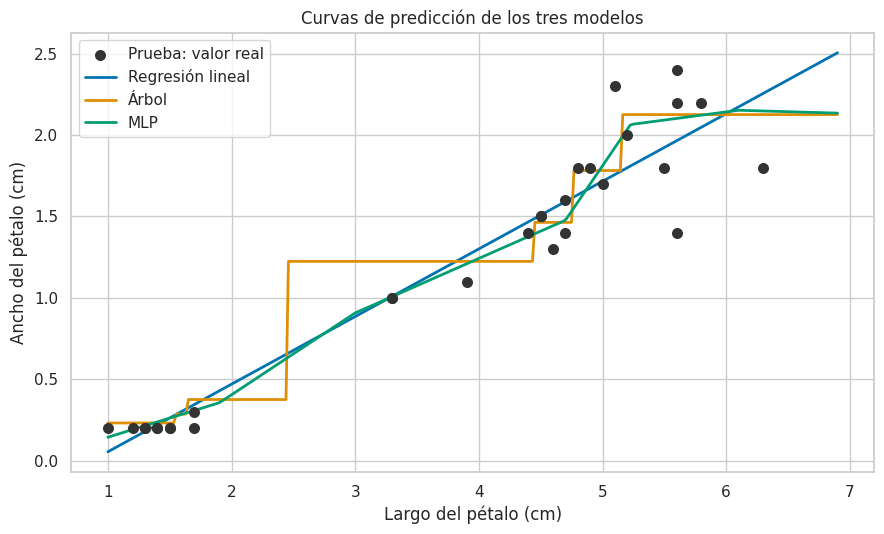

In [13]:
grilla=np.linspace(df['largo_petalo_cm'].min(),df['largo_petalo_cm'].max(),300).reshape(-1,1)
fig,ax=plt.subplots(figsize=(9,5.5))
ax.scatter(X_test['largo_petalo_cm'],y_test,c='#333333',s=48,label='Prueba: valor real',zorder=5)
ax.plot(grilla[:,0],modelo_lineal.predict(grilla),label='Regresión lineal',lw=2)
ax.plot(grilla[:,0],modelo_arbol.predict(grilla),label='Árbol',lw=2)
ax.plot(grilla[:,0],modelo_mlp.predict(grilla),label='MLP',lw=2)
ax.set(xlabel='Largo del pétalo (cm)',ylabel='Ancho del pétalo (cm)',title='Curvas de predicción de los tres modelos')
ax.legend(); fig.tight_layout(); fig.savefig(FIG_DIR/'figura_4_curvas_modelos.png',dpi=220,bbox_inches='tight'); plt.show()

### Interpretación de métricas

- **MSE:** penaliza con mayor fuerza errores grandes; valores menores indican menor error cuadrático.
- **RMSE:** expresa el error típico en la unidad original de la variable objetivo (centímetros), facilitando la interpretación.
- **R²:** indica la proporción de variabilidad del ancho del pétalo explicada en prueba; valores más altos implican mayor capacidad explicativa, sin demostrar causalidad.

La selección se realiza conjuntamente: menor MSE/RMSE y mayor R².

## 9. Comparación crítica

In [14]:
comparacion = pd.DataFrame([
 ['Regresión lineal simple','Alta','Relación global clara','No captura curvaturas locales'],
 ['Árbol de decisión','Alta','Reglas y tramos interpretables','Predicción escalonada; sensible a profundidad'],
 ['Red neuronal MLP','Media-baja','Flexibilidad no lineal y menor error','Mayor complejidad; requiere escalamiento']
],columns=['Modelo','Interpretabilidad','Fortaleza','Limitación'])
display(comparacion)
comparacion.to_csv(RES_DIR/'comparacion_cualitativa.csv',index=False,encoding='utf-8-sig')

,Modelo,Interpretabilidad,Fortaleza,Limitación
0,Regresión lineal simple,Alta,Relación global clara,No captura curvaturas locales
1,Árbol de decisión,Alta,Reglas y tramos interpretables,Predicción escalonada; sensible a profundidad
2,Red neuronal MLP,Media-baja,Flexibilidad no lineal y menor error,Mayor complejidad; requiere escalamiento


**Decisión analítica.** La MLP es el modelo seleccionado por presentar simultáneamente el menor RMSE y el mayor R² en las 30 observaciones de prueba. Sin embargo, la ventaja cuantitativa es moderada y el tamaño de Iris es reducido; por ello, el resultado debe interpretarse como evidencia inicial y no como superioridad universal. La regresión lineal continúa siendo una alternativa valiosa cuando la prioridad sea explicar el efecto promedio, mientras el árbol ofrece reglas locales comprensibles.

## 10. Validación integral, exportación y trazabilidad

In [15]:
detalle = pd.DataFrame({
    'indice_original': y_test.index,
    'largo_petalo_cm': X_test['largo_petalo_cm'].values,
    'ancho_real_cm': y_test.values,
    'pred_lineal_cm': pred_lineal,
    'pred_arbol_cm': pred_arbol,
    'pred_mlp_cm': pred_mlp
}).sort_values('indice_original')
detalle.to_csv(RES_DIR/'predicciones_prueba.csv',index=False,encoding='utf-8-sig')

assert resultados.shape==(3,4)
assert np.isfinite(resultados[['MSE','RMSE','R2']].to_numpy()).all()
assert (resultados['MSE']>=0).all() and (resultados['RMSE']>=0).all()
assert len(pred_lineal)==len(pred_arbol)==len(pred_mlp)==len(y_test)==30
assert (FIG_DIR/'figura_3_metricas.png').exists()
assert (RES_DIR/'metricas_modelos.csv').exists()

print('='*72)
print('FORMativa 2 · MCDI504 · GRUPO 7')
print('Carga y calidad: COMPLETADAS')
print('Partición reproducible: COMPLETADA')
print('Tres modelos: COMPLETADOS')
print('MSE, RMSE y R²: COMPLETADOS')
print('Figuras y resultados: EXPORTADOS')
print('VALIDACIÓN INTEGRAL SUPERADA')
print('='*72)

FORMativa 2 · MCDI504 · GRUPO 7
Carga y calidad: COMPLETADAS
Partición reproducible: COMPLETADA
Tres modelos: COMPLETADOS
MSE, RMSE y R²: COMPLETADOS
Figuras y resultados: EXPORTADOS
VALIDACIÓN INTEGRAL SUPERADA


## 11. Conclusiones

1. El largo del pétalo posee una relación predictiva intensa con su ancho y permite formular un problema de regresión simple dentro del mismo dataset Iris de la Fase 1.
2. Los tres modelos generalizan adecuadamente en la partición de prueba, con R² superior a 0,92.
3. La MLP obtiene el mejor desempeño predictivo del ejercicio, seguida estrechamente por el árbol y la regresión lineal.
4. La decisión no debe basarse solo en una métrica: la MLP favorece precisión; la regresión lineal, interpretación; y el árbol, reglas locales.
5. Para una fase posterior conviene incorporar validación cruzada y evaluar estabilidad antes de ampliar hiperparámetros o variables.

### Relación con el repositorio

El archivo debe ubicarse como `03_Notebooks/F2_Regresion.ipynb`; las figuras y tablas generadas se exportan a `05_Figuras/` y `06_Resultados/`. El informe institucional debe referenciar exactamente estos nombres para conservar trazabilidad.

## Referencias técnicas

- Universidad Andrés Bello. (2026). *Regresión lineal simple, polinomial y multivariable* [Apunte de clase].
- Universidad Andrés Bello. (2026). *Regresión con árboles de decisión* [Apunte de clase].
- Universidad Andrés Bello. (2026). *Regresión con redes neuronales artificiales* [Apunte de clase].
- Scikit-learn developers. (2026). *LinearRegression*. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- Scikit-learn developers. (2026). *DecisionTreeRegressor*. https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html
- Scikit-learn developers. (2026). *MLPRegressor*. https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html
- Fisher, R. A. (1936). The use of multiple measurements in taxonomic problems. *Annals of Eugenics, 7*(2), 179–188. https://doi.org/10.1111/j.1469-1809.1936.tb02137.x